In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/cleaned_master.csv', parse_dates=['order_purchase_timestamp'])
print(df.shape)

(115030, 31)


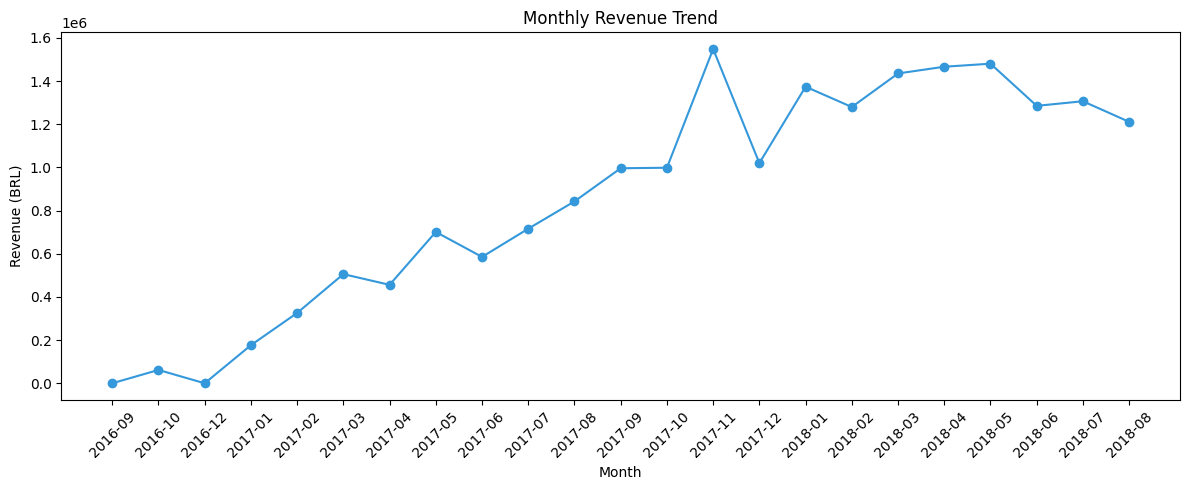

In [2]:
# extract year-month from order date
df['year_month'] = df['order_purchase_timestamp'].dt.to_period('M')

# monthly revenue
monthly_revenue = df.groupby('year_month')['payment_value'].sum().reset_index()
monthly_revenue['year_month'] = monthly_revenue['year_month'].astype(str)

plt.figure(figsize=(12, 5))
plt.plot(monthly_revenue['year_month'], monthly_revenue['payment_value'], marker='o', color='#3498db')
plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Revenue (BRL)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../images/monthly_revenue.png')
plt.show()

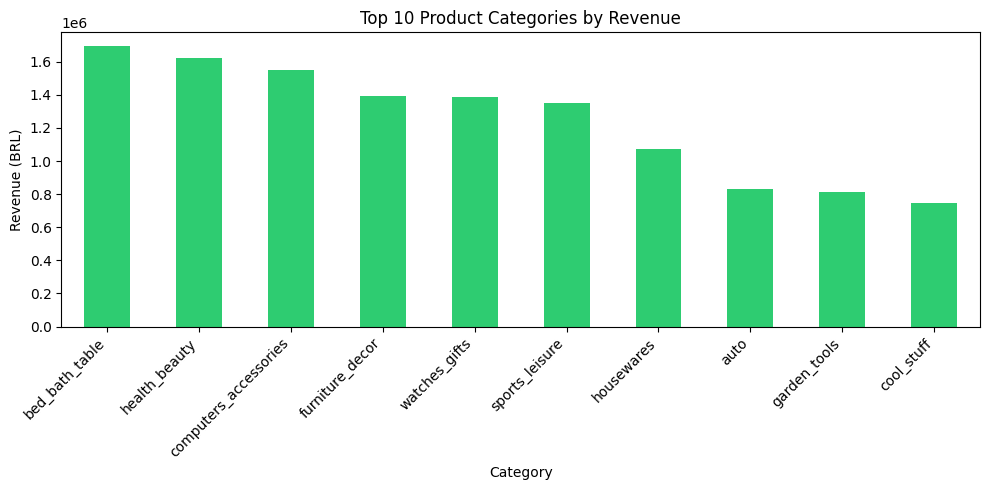

In [3]:
# top 10 product categories by revenue
top_categories = df.groupby('product_category_name_english')['payment_value'].sum()
top_categories = top_categories.sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 5))
top_categories.plot(kind='bar', color='#2ecc71')
plt.title('Top 10 Product Categories by Revenue')
plt.xlabel('Category')
plt.ylabel('Revenue (BRL)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../images/top_categories.png')
plt.show()

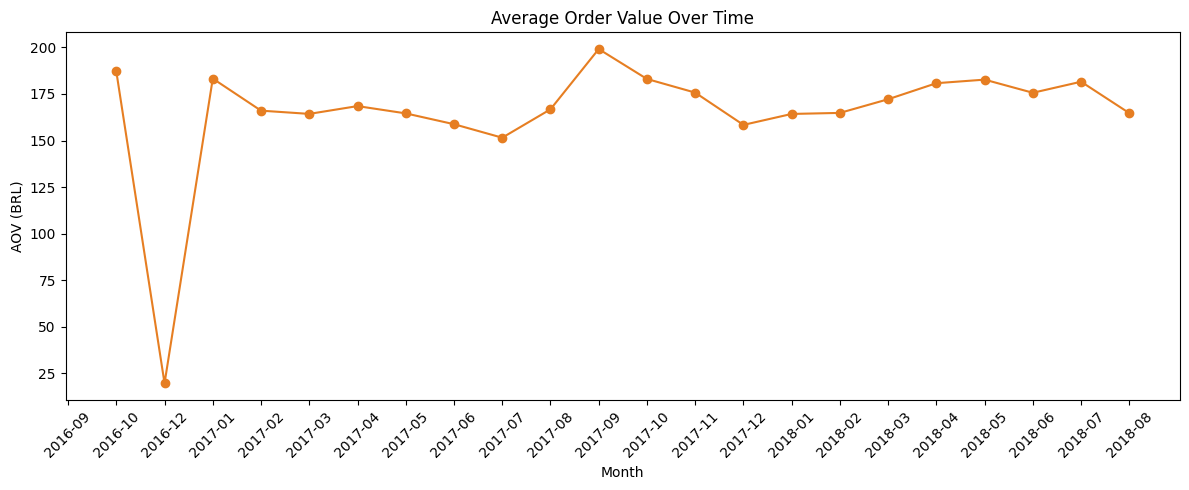

In [4]:
# average order value per month
aov = df.groupby('year_month')['payment_value'].mean().reset_index()
aov['year_month'] = aov['year_month'].astype(str)

plt.figure(figsize=(12, 5))
plt.plot(aov['year_month'], aov['payment_value'], marker='o', color='#e67e22')
plt.title('Average Order Value Over Time')
plt.xlabel('Month')
plt.ylabel('AOV (BRL)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../images/aov_trend.png')
plt.show()